## **EFICIENCIA Y SEPARACION DE PILOTES**

Univ. Espinoza Vicuña Favio Brayan

---


Para el cálculo de la eficiencia y el espaciamiento de cualquier grupo de pilotes como se muestra en la figura:

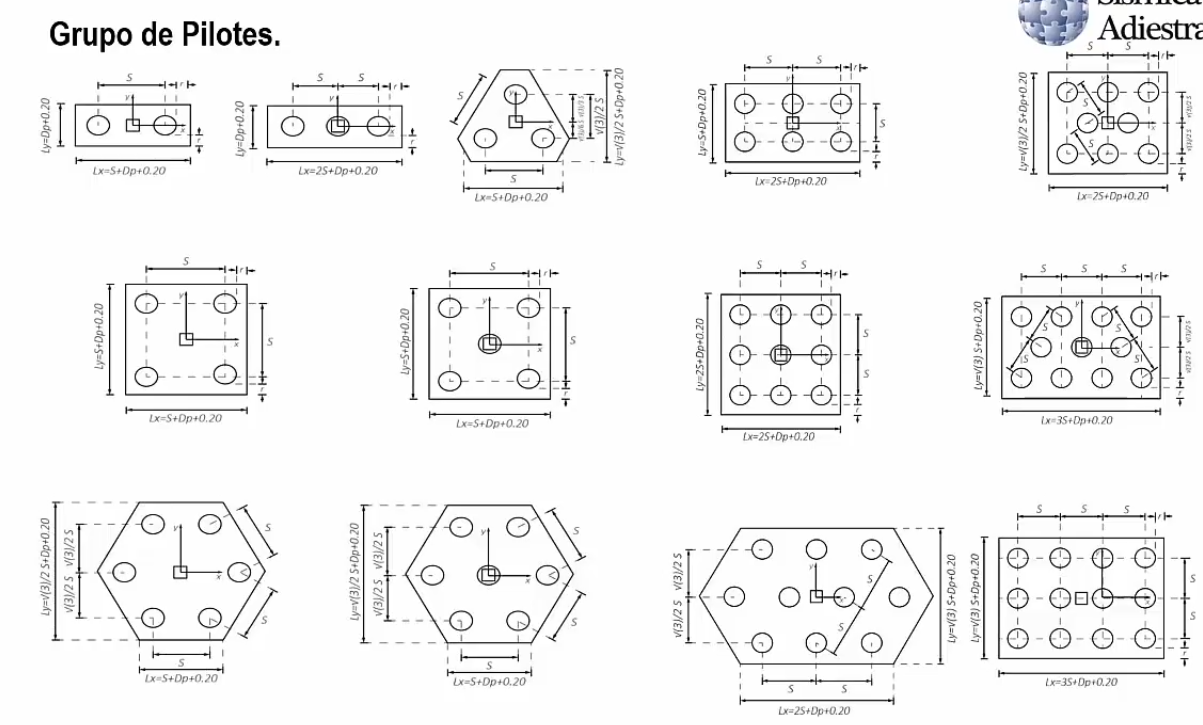


---

Para el cálculo del espaciamiento $d$ entre pilotes usaremos la teria de Braja Das.

Entonces:

$$d\geq3D$$

---

Para el calculo de la eficiencia antes necesitamos saber algunas cosas:



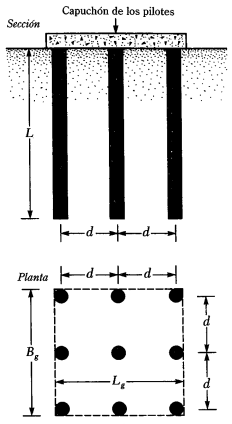

El número de pilotes de grupo sera: $n_1$ x $n_2$

DONDE:

- $n_1$= Numero de filas de un grupo de pilotes
- $n_2$= Numero de columnas de un grupo de pilotes

---


Para la eficiencia vamos a utilizar la siguiente fórmula: Según Braja Das.

$$\eta =  \frac{2(n_1+n_2-2)d + 4D}{pn_1n_2}$$

DONDE:

- $\eta$ = Eficiencia del grupo de pilotes
- $d$ = Espaciamiento de centro a centro
- $D$ = Diametro del pilote
- $p$ = perimetro de del pilote


Aplicando ecuaciones empiricas para determinar la eficiencia de grupo de pilotes:

- **Ecuación Converse-Labarre:**

$$\eta = 1 - \frac{\theta}{90} \left[ \frac{(n_1-1)n_2 + (n_2-1)n_1}{n_1n_2} \right]$$

Donde $\theta = \arctan(D/d)$ en grados.

---

- **Ecuación los Angeles:**

$$\eta = 1 - \frac{D}{\pi dn_1n_2} \left[ n_1(n_2-1)+n_2(n_1-1)+\sqrt{2}(n_1-1)(n_2-1) \right]$$

---

- **Ecuación de Seiler-Keeney:**

$$\eta =  1 - \frac{11d}{7(d^2 - 1)}* \frac{n_1+n_2-2}{n_1+n_2-1}  + \frac{0.3}{n_1+n_2}$$


- **Feld:**

Sugirio un metodo para determinar la capacidad de carga de pilotes individuales en un grupo  de pilotes en arena cuando solamente se considera la resistencia por friccion. De acuerdo a esto, la capacidad ultima de un pilote se reduce en 1/16 por cada pilote adyacente.




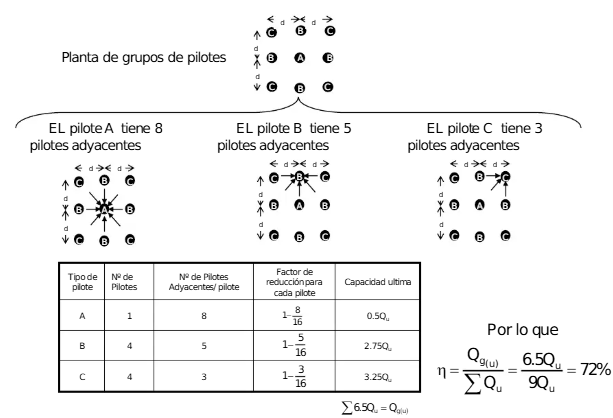


 ## 1. Para un grupo de pilotes circular:
  



In [35]:
import math

def calcular_eficiencia_braja(n1, n2, D, d):
    p = math.pi * D
    numerador = (2 * (n1 + n2 - 2) * d) + (4 * D)
    denominador = p * n1 * n2
    return numerador / denominador

def calcular_converse_labarre(n1, n2, D, d):
    theta = math.degrees(math.atan(D / d))
    termino_n = ((n1 - 1) * n2 + (n2 - 1) * n1) / (n1 * n2)
    return 1 - (theta / 90) * termino_n

def calcular_los_angeles(n1, n2, D, d):
    termino_parentesis = n1*(n2-1) + n2*(n1-1) + math.sqrt(2)*(n1-1)*(n2-1)
    return 1 - (D / (math.pi * d * n1 * n2)) * termino_parentesis

def calcular_seiler_keeney(n1, n2, d):
    # d_ft: convirtiendo metros a pies para la fórmula empírica
    d_ft = d / 0.3048
    termino1 = (11 * d_ft) / (7 * (d_ft**2 - 1))
    termino2 = (n1 + n2 - 2) / (n1 + n2 - 1)
    termino3 = 0.3 / (n1 + n2)
    return 1 - (termino1 * termino2) + termino3

# Ejemplo de uso
n1_val = 2
n2_val = 3
D_val = 0.71  # Diámetro
d_val = 2.13  # Espaciamiento (ejemplo 3D)

res_braja = calcular_eficiencia_braja(n1_val, n2_val, D_val, d_val)
res_converse = calcular_converse_labarre(n1_val, n2_val, D_val, d_val)
res_la = calcular_los_angeles(n1_val, n2_val, D_val, d_val)
res_sk = calcular_seiler_keeney(n1_val, n2_val, d_val)

print(f"--- Resultados Pilote CIRCULAR ---")
print(f"1. Braja Das:         {res_braja:.4f}")
print(f"2. Converse-Labarre:  {res_converse:.4f}")
print(f"3. Los Angeles:       {res_la:.4f}")
print(f"4. Seiler-Keeney:     {res_sk:.4f}")

--- Resultados Pilote CIRCULAR ---
1. Braja Das:         1.1671
2. Converse-Labarre:  0.7610
3. Los Angeles:       0.8262
4. Seiler-Keeney:     0.8878



## 2. Gráfico de Eficiencia para Pilotes Circulares


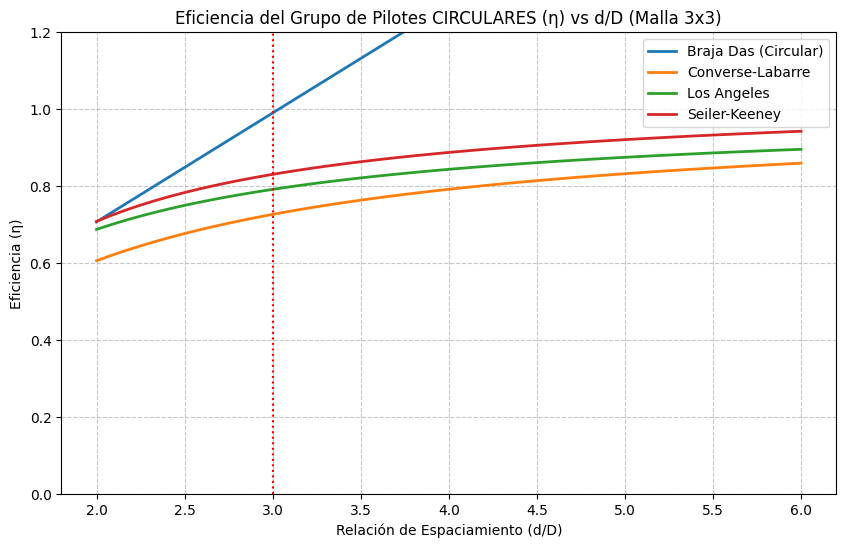

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Parámetros para el grupo de pilotes circulares
ratio_range_circ = np.linspace(2, 6, 50)
n1_circ, n2_circ = 3, 3  # Malla de ejemplo
D_circ = 0.60 # Diámetro en metros

ef_braja_c, ef_converse_c, ef_la_c, ef_sk_c = [], [], [], []

for r in ratio_range_circ:
    d_current = r * D_circ
    ef_braja_c.append(calcular_eficiencia_braja(n1_circ, n2_circ, D_circ, d_current))
    ef_converse_c.append(calcular_converse_labarre(n1_circ, n2_circ, D_circ, d_current))
    ef_la_c.append(calcular_los_angeles(n1_circ, n2_circ, D_circ, d_current))
    ef_sk_c.append(calcular_seiler_keeney(n1_circ, n2_circ, d_current))

# Crear el gráfico circular
plt.figure(figsize=(10, 6))
plt.plot(ratio_range_circ, ef_braja_c, label='Braja Das (Circular)', linewidth=2, color='tab:blue')
plt.plot(ratio_range_circ, ef_converse_c, label='Converse-Labarre', linewidth=2, color='tab:orange')
plt.plot(ratio_range_circ, ef_la_c, label='Los Angeles', linewidth=2, color='tab:green')
plt.plot(ratio_range_circ, ef_sk_c, label='Seiler-Keeney', linewidth=2, color='tab:red')

plt.title(f'Eficiencia del Grupo de Pilotes CIRCULARES (η) vs d/D (Malla {n1_circ}x{n2_circ})')
plt.xlabel('Relación de Espaciamiento (d/D)')
plt.ylabel('Eficiencia (η)')
plt.ylim(0, 1.2)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.axvline(x=3, color='red', linestyle=':', label='d=3D')
plt.show()

## 3. Para un pilote cuadrado:

In [30]:
import math

def calcular_eficiencia_braja_cuadrado(n1, n2, b, N):
    # Diámetro equivalente (diagonal del cuadrado)
    D = (2 * b**2)**0.5
    # Perímetro del pilote cuadrado
    p = 4 * b
    # Espaciamiento
    d = N * D
    # Fórmula de eficiencia Braja Das
    numerador = (2 * (n1 + n2 - 2) * d) + (4 * D)
    denominador = p * n1 * n2
    eficiencia = numerador / denominador
    return eficiencia, D, d

def calcular_converse_labarre(n1, n2, D, d):
    theta = math.degrees(math.atan(D / d))
    termino_n = ((n1 - 1) * n2 + (n2 - 1) * n1) / (n1 * n2)
    return 1 - (theta / 90) * termino_n

def calcular_los_angeles(n1, n2, D, d):
    # Ecuación Los Angeles
    termino_parentesis = n1*(n2-1) + n2*(n1-1) + math.sqrt(2)*(n1-1)*(n2-1)
    eficiencia = 1 - (D / (math.pi * d * n1 * n2)) * termino_parentesis
    return eficiencia

def calcular_seiler_keeney(n1, n2, d_ft):
    # Nota: La fórmula de Seiler-Keeney suele expresarse con el espaciamiento en pies (ft)
    # d es el espaciamiento de centro a centro
    termino1 = (11 * d_ft /0.3048) / (7 * ((d_ft/0.3048)**2 - 1))
    termino2 = (n1 + n2 - 2) / (n1 + n2 - 1)
    termino3 = 0.3 / (n1 + n2)
    eficiencia = 1 - (termino1 * termino2) + termino3
    return eficiencia

# Ejemplo de uso
n1_val = 2
n2_val = 3
b_val = 0.5
N_val = 3

eficiencia_braja, diam_eq, espaciamiento = calcular_eficiencia_braja_cuadrado(n1_val, n2_val, b_val, N_val)
eficiencia_converse = calcular_converse_labarre(n1_val, n2_val, diam_eq, espaciamiento)
eficiencia_la = calcular_los_angeles(n1_val, n2_val, diam_eq, espaciamiento)
eficiencia_sk = calcular_seiler_keeney(n1_val, n2_val, espaciamiento)

# Imprimiendo múltiples resultados
print(f"--- Resultados Pilote Cuadrado ---")
print(f"Diámetro equivalente (D): {diam_eq:.4f}")
print(f"Espaciamiento (d): {espaciamiento:.4f}")
print(f"--- Comparativa de Eficiencias ---")
print(f"1. Braja Das:         {eficiencia_braja:.4f}")
print(f"2. Converse-Labarre:  {eficiencia_converse:.4f}")
print(f"3. Los Angeles:       {eficiencia_la:.4f}")
print(f"4. Seiler-Keeney:     {eficiencia_sk:.4f}")

--- Resultados Pilote Cuadrado ---
Diámetro equivalente (D): 0.7071
Espaciamiento (d): 2.1213
--- Comparativa de Eficiencias ---
1. Braja Das:         1.2964
2. Converse-Labarre:  0.7610
3. Los Angeles:       0.8262
4. Seiler-Keeney:     0.8871


## 4. Gráfico de Eficiencia para Pilotes Rectangulares


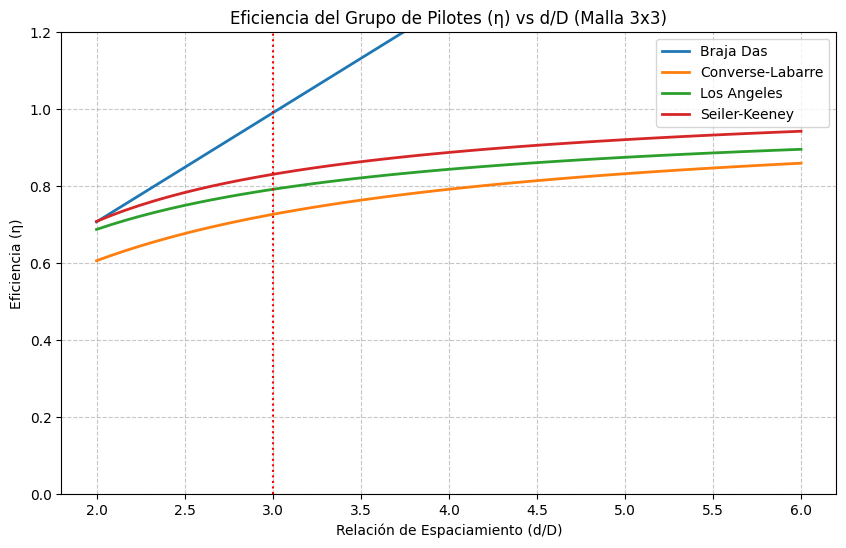

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Definimos un rango de d/D (relación espaciamiento/diámetro) de 2 a 6
ratio_range = np.linspace(2, 6, 50)
n1_plot, n2_plot = 3, 3  # Ejemplo para una malla de 3x3
D_plot = 0.60 # Diámetro de ejemplo en metros

ef_braja, ef_converse, ef_la, ef_sk = [], [], [], []

for r in ratio_range:
    d_current = r * D_plot
    ef_braja.append(calcular_eficiencia_braja(n1_plot, n2_plot, D_plot, d_current))
    ef_converse.append(calcular_converse_labarre(n1_plot, n2_plot, D_plot, d_current))
    ef_la.append(calcular_los_angeles(n1_plot, n2_plot, D_plot, d_current))
    ef_sk.append(calcular_seiler_keeney(n1_plot, n2_plot, d_current))

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(ratio_range, ef_braja, label='Braja Das', linewidth=2)
plt.plot(ratio_range, ef_converse, label='Converse-Labarre', linewidth=2)
plt.plot(ratio_range, ef_la, label='Los Angeles', linewidth=2)
plt.plot(ratio_range, ef_sk, label='Seiler-Keeney', linewidth=2)

plt.title(f'Eficiencia del Grupo de Pilotes (η) vs d/D (Malla {n1_plot}x{n2_plot})')
plt.xlabel('Relación de Espaciamiento (d/D)')
plt.ylabel('Eficiencia (η)')
plt.ylim(0, 1.2) # Ajuste del valor máximo solicitado
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.axvline(x=3, color='red', linestyle=':', label='d=3D')
plt.show()

## 5. FELD: Para un grupo de pilotes en Arena

Esta programado solo para aquellos que contengan un numero de filas por un numero de columnas.

In [40]:
def calcular_eficiencia_feld(n1, n2):
    """
    Calcula la eficiencia de un grupo de pilotes usando el método de Feld.
    Reduce la capacidad en 1/16 (0.0625) por cada pilote adyacente.
    """
    reducciones = []

    for i in range(n1):
        for j in range(n2):
            adyacentes = 0
            # Revisar las 8 posiciones alrededor del pilote (i, j)
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n1 and 0 <= nj < n2:
                        adyacentes += 1

            # Capacidad individual = 1 - (adyacentes * 1/16)
            capacidad_relativa = 1 - (adyacentes / 16.0)
            reducciones.append(capacidad_relativa)

    # Eficiencia del grupo = promedio de las capacidades individuales
    eficiencia_grupo = sum(reducciones) / len(reducciones)
    return eficiencia_grupo, reducciones

# Ejemplo para una malla de 3x3
n1_feld, n2_feld = 2, 3
ef_total, lista_indiv = calcular_eficiencia_feld(n1_feld, n2_feld)

print(f"--- Método de Feld (Malla {n1_feld}x{n2_feld}) ---")
print(f"Eficiencia total del grupo: {ef_total:.4f}")
print("\nCapacidad relativa por posición:")
for idx, cap in enumerate(lista_indiv):
    fila = idx // n2_feld
    col = idx % n2_feld
    print(f"Pilote [{fila+1},{col+1}]: {cap:.4f}")

--- Método de Feld (Malla 2x3) ---
Eficiencia total del grupo: 0.7708

Capacidad relativa por posición:
Pilote [1,1]: 0.8125
Pilote [1,2]: 0.6875
Pilote [1,3]: 0.8125
Pilote [2,1]: 0.8125
Pilote [2,2]: 0.6875
Pilote [2,3]: 0.8125


## **INTERPRETACION DE EFICIENCIAS**

 **RESUMEN**

| Eficiencia | Significado | Interpretación |
| :--- | :--- | :--- |
| $\eta = 1$ | Ideal | Sin interferencia |
| $\eta < 1$ | Normal | Hay pérdida de capacidad |
| $\eta > 1$ | Especial | Mejora del suelo |

---


 **En la mayoría de diseños reales:**
$\eta < 1$, porque la interacción suelo–pilote suele reducir la eficiencia por la superposición de bulbos de presión.

## **COMPARATIVA FINAL DE RESULTADOS**
Esta celda unifica todos los métodos aplicados anteriormente para facilitar la toma de decisiones.

In [43]:
import pandas as pd

# Parámetros de diseño final
n1_f, n2_f = 3, 3
D_f = 0.60 # metros
d_f = 1.80 # metros (3D)

# Cálculos
ef_b = calcular_eficiencia_braja(n1_f, n2_f, D_f, d_f)
ef_cl = calcular_converse_labarre(n1_f, n2_f, D_f, d_f)
ef_la = calcular_los_angeles(n1_f, n2_f, D_f, d_f)
ef_sk = calcular_seiler_keeney(n1_f, n2_f, d_f)
ef_fe, _ = calcular_eficiencia_feld(n1_f, n2_f)

# Crear tabla resumen
resumen = {
    'Método': ['Braja Das', 'Converse-Labarre', 'Los Angeles', 'Seiler-Keeney', 'Feld (Arena)'],
    'Eficiencia (η)': [ef_b, ef_cl, ef_la, ef_sk, ef_fe]
}

df_resumen = pd.DataFrame(resumen)
display(df_resumen.style.highlight_max(subset=['Eficiencia (η)'], color='lightgreen').highlight_min(subset=['Eficiencia (η)'], color='coral'))

,Método,Eficiencia (η)
0,Braja Das,0.990297
1,Converse-Labarre,0.726890
2,Los Angeles,0.791839
3,Seiler-Keeney,0.830840
4,Feld (Arena),0.722222
